In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform
from sbi.analysis import pairplot

# --- CONNEXION À JULIA ---
from juliacall import Main as jl

jl.include("passerelle.jl")


# --- DÉFINITION DU SIMULATEUR POUR SBI ---
def simulateur_sbi_hybride(theta):
    theta = torch.atleast_2d(theta)
    resultats_simules = []

    for jeu_de_parametres in theta:
        val_ampa = float(jeu_de_parametres[0])
        val_nmda = float(jeu_de_parametres[1])
        
        t_julia, v_julia, ca_julia = jl.simuler_synapse_brute(val_ampa, val_nmda)
        
        t_fixe = np.linspace(float(t_julia[0]), float(t_julia[-1]), 500)
        v_fixe = np.interp(t_fixe, list(t_julia), list(v_julia))
        ca_fixe = np.interp(t_fixe, list(t_julia), list(ca_julia))
        
        courbe_combinee = np.concatenate([v_fixe, ca_fixe])
        courbe_pytorch = torch.tensor(courbe_combinee, dtype=torch.float32)
        resultats_simules.append(courbe_pytorch)
        
    return torch.stack(resultats_simules)


# --- PROTOCOLE MACHINE LEARNING (SBI) ---

prior = BoxUniform(
    low=torch.tensor([0.001, 0.001]), 
    high=torch.tensor([0.1, 0.1])
)

print("\nLancement des simulations de l'IA")
theta_sim, x_sim = simulate_for_sbi(simulateur_sbi_hybride, prior, num_simulations=1000, show_progress_bar=False)

print("Entraînement du réseau de neurones...")
inference = NPE(prior)
inference.append_simulations(theta_sim, x_sim)
inference.train()
posterior = inference.build_posterior()

print("Interface validée ! L'IA est entraînée et prête à l'inférence.")




  Activating new project at `~/derryInternship/SynapseElife.jl/sbi`



Lancement des simulations de l'IA
  0.154294 seconds (827.60 k allocations: 27.646 MiB)
  0.184072 seconds (882.32 k allocations: 29.926 MiB)
  0.225083 seconds (813.70 k allocations: 27.643 MiB, 23.31% gc time)
  0.144708 seconds (795.80 k allocations: 26.760 MiB)
  0.172482 seconds (865.94 k allocations: 29.337 MiB)
  0.172156 seconds (885.42 k allocations: 29.719 MiB)
  0.130419 seconds (686.72 k allocations: 23.504 MiB)
  0.146583 seconds (767.14 k allocations: 25.910 MiB)
  0.156899 seconds (803.85 k allocations: 26.934 MiB)
  0.155849 seconds (769.51 k allocations: 26.094 MiB)
  0.155187 seconds (793.31 k allocations: 26.817 MiB)
  0.139694 seconds (739.65 k allocations: 26.014 MiB)
  0.160699 seconds (808.91 k allocations: 27.249 MiB)
  0.216431 seconds (720.86 k allocations: 24.802 MiB, 8.73% gc time)
  0.253887 seconds (786.19 k allocations: 26.651 MiB, 37.45% gc time)
  0.779242 seconds (702.68 k allocations: 23.796 MiB, 79.96% gc time)
  0.161064 seconds (718.64 k allocatio

/home/jean/derryInternship/SynapseElife.jl/sbi/env_sbi/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has constant values in dimension(s) [0, 500]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 35 epochs.Interface validée ! L'IA est entraînée et prête à l'inférence.



--- TEST SCIENTIFIQUE (AVEC CALCIUM) ---
Génération de l'expérience secrète (AMPA=0.08, NMDA=0.02)...
L'IA tente de retrouver les valeurs secrètes à partir du Voltage ET du Calcium...


10052it [00:00, 69314.46it/s]                          


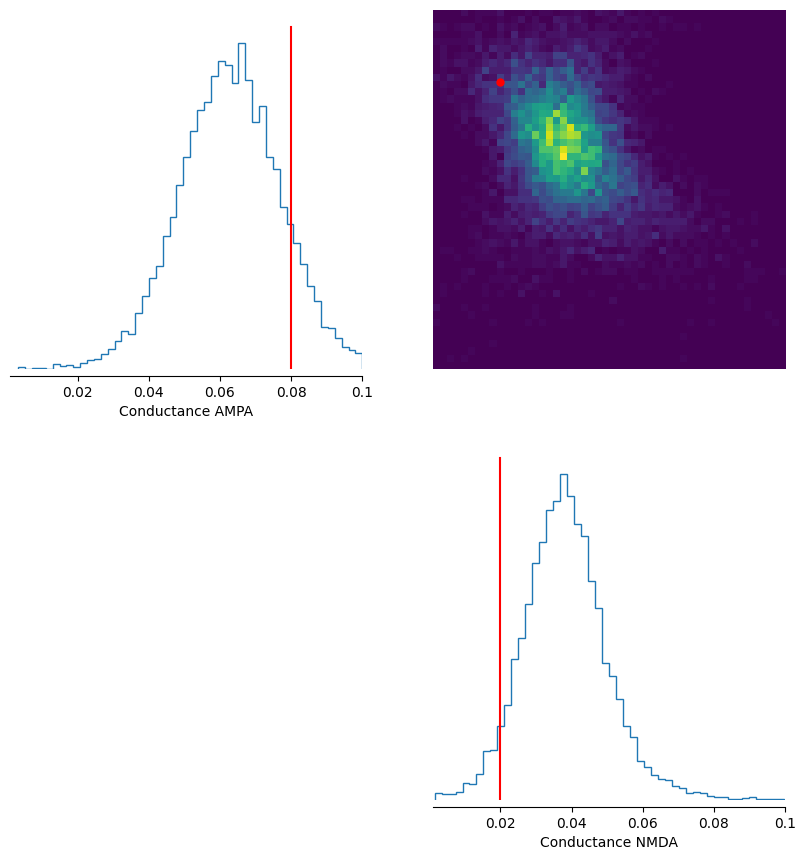

  0.139499 seconds (798.89 k allocations: 27.016 MiB)


In [52]:
print("\n--- TEST SCIENTIFIQUE (AVEC CALCIUM) ---")
vrai_ampa = 0.08
vrai_nmda = 0.02
print(f"Génération de l'expérience secrète (AMPA={vrai_ampa}, NMDA={vrai_nmda})...")

# On réceptionne les 3 variables pour la courbe secrète
t_cible, v_cible, ca_cible = jl.simuler_synapse_brute(vrai_ampa, vrai_nmda)

# On lisse et on combine exactement de la même manière
t_fixe = np.linspace(float(t_cible[0]), float(t_cible[-1]), 500)
v_fixe = np.interp(t_fixe, list(t_cible), list(v_cible))
ca_fixe = np.interp(t_fixe, list(t_cible), list(ca_cible))

courbe_cible_combinee = torch.tensor(np.concatenate([v_fixe, ca_fixe]), dtype=torch.float32)

print("L'IA tente de retrouver les valeurs secrètes à partir du Voltage ET du Calcium...")
echantillons_devines = posterior.sample((10000,), x=courbe_cible_combinee)

fig, axes = pairplot(
    echantillons_devines,
    limits=[[0.001, 0.1], [0.001, 0.1]], 
    labels=["Conductance AMPA", "Conductance NMDA"],
    points=[[vrai_ampa, vrai_nmda]], 
    points_colors=["red"]
)
plt.show()